In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import shap
from google.colab import drive, files
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, PolynomialFeatures ,  LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn import ensemble, gaussian_process, linear_model, naive_bayes, neighbors, svm, tree, discriminant_analysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from collections import Counter
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import RFE
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/train (3).csv")
test_df = pd.read_csv("/content/drive/MyDrive/test (3).csv")
sample_df=pd.read_csv("/content/drive/MyDrive/sample_submission (1).csv")

## 1. preprocessing and EDA

In [ ]:

train_df.shape
train_df

,Unnamed: 0,age_years,travel_freq,daily_salary,work_division,commute_distance,education_level,degree_field,headcount,env_satisfaction,...,std_work_hours,stock_level,career_years,trainings_last_year,work_life_score,tenure_years,years_current_role,years_post_promotion,years_with_manager,left_company
0,0,27,frequent_travel,1302,rnd,2,2,life_sci,1,2,...,80,1,8,5,3,8,7,0,1,0
1,1,32,rare_travel,1476,rnd,28,2,life_sci,1,1,...,80,0,8,3,3,4,1,1,3,0
2,2,44,rare_travel,1275,rnd,9,2,medical,1,3,...,80,1,10,2,3,9,8,1,7,0
3,3,46,rare_travel,1320,sales,24,4,marketing,1,4,...,80,1,28,3,3,22,11,15,8,0
4,4,42,rare_travel,442,rnd,1,4,life_sci,1,1,...,80,1,10,3,1,8,7,0,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1336,1336,35,rare_travel,584,rnd,11,2,life_sci,1,4,...,80,0,10,2,3,10,0,3,9,0
1337,1337,31,rare_travel,1082,sales,6,4,other,1,2,...,80,1,4,3,2,3,2,1,2,0
1338,1338,36,no_travel,855,rnd,1,4,life_sci,1,1,...,80,2,10,3,2,10,7,7,7,0
1339,1339,27,frequent_travel,1225,sales,5,2,life_sci,1,3,...,80,1,3,2,3,3,2,0,2,0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Unnamed: 0             1341 non-null   int64 
 1   age_years              1341 non-null   int64 
 2   travel_freq            1341 non-null   object
 3   daily_salary           1341 non-null   int64 
 4   work_division          1341 non-null   object
 5   commute_distance       1341 non-null   int64 
 6   education_level        1341 non-null   int64 
 7   degree_field           1341 non-null   object
 8   headcount              1341 non-null   int64 
 9   env_satisfaction       1341 non-null   int64 
 10  sex                    1341 non-null   object
 11  hourly_wage            1341 non-null   int64 
 12  job_engagement         1341 non-null   int64 
 13  position_level         1341 non-null   int64 
 14  job_title              1341 non-null   object
 15  job_satisfaction     

In [ ]:
# Check for missing values
print("\nMissing Values:")
print(train_df.isnull().sum())


Missing Values:
Unnamed: 0               0
age_years                0
travel_freq              0
daily_salary             0
work_division            0
commute_distance         0
education_level          0
degree_field             0
headcount                0
env_satisfaction         0
sex                      0
hourly_wage              0
job_engagement           0
position_level           0
job_title                0
job_satisfaction         0
marital_state            0
monthly_earnings         0
monthly_salary           0
companies_count          0
is_adult                 0
overtime_status          0
salary_increase_pct      0
performance_score        0
relation_satisfaction    0
std_work_hours           0
stock_level              0
career_years             0
trainings_last_year      0
work_life_score          0
tenure_years             0
years_current_role       0
years_post_promotion     0
years_with_manager       0
left_company             0
dtype: int64


In [ ]:
#  categorical col
cat_columns = train_df.select_dtypes(include='object').columns
print("\nCategorical Columns:", cat_columns.tolist())


Categorical Columns: ['travel_freq', 'work_division', 'degree_field', 'sex', 'job_title', 'marital_state', 'is_adult', 'overtime_status']


In [ ]:
#  unique values per categorical col
for col in cat_columns:
    print(col)
    print(train_df[col].nunique())

travel_freq
3
work_division
3
degree_field
6
sex
2
job_title
9
marital_state
3
is_adult
1
overtime_status
2


In [ ]:
#Categorial to Numerical Train
train_datas = train_df.select_dtypes(include=['object']).columns
for col in train_datas:
    train_df[col] = pd.factorize(train_df[col])[0]



#Categorial  to Numerical Test
test_datas = test_df.select_dtypes(include=['object']).columns
for col in test_datas:
    test_df[col] = pd.factorize(test_df[col])[0]

In [ ]:
train_df

,Unnamed: 0,age_years,travel_freq,daily_salary,work_division,commute_distance,education_level,degree_field,headcount,env_satisfaction,...,std_work_hours,stock_level,career_years,trainings_last_year,work_life_score,tenure_years,years_current_role,years_post_promotion,years_with_manager,left_company
0,0,27,0,1302,0,2,2,0,1,2,...,80,1,8,5,3,8,7,0,1,0
1,1,32,1,1476,0,28,2,0,1,1,...,80,0,8,3,3,4,1,1,3,0
2,2,44,1,1275,0,9,2,1,1,3,...,80,1,10,2,3,9,8,1,7,0
3,3,46,1,1320,1,24,4,2,1,4,...,80,1,28,3,3,22,11,15,8,0
4,4,42,1,442,0,1,4,0,1,1,...,80,1,10,3,1,8,7,0,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1336,1336,35,1,584,0,11,2,0,1,4,...,80,0,10,2,3,10,0,3,9,0
1337,1337,31,1,1082,1,6,4,4,1,2,...,80,1,4,3,2,3,2,1,2,0
1338,1338,36,2,855,0,1,4,0,1,1,...,80,2,10,3,2,10,7,7,7,0
1339,1339,27,0,1225,1,5,2,0,1,3,...,80,1,3,2,3,3,2,0,2,0


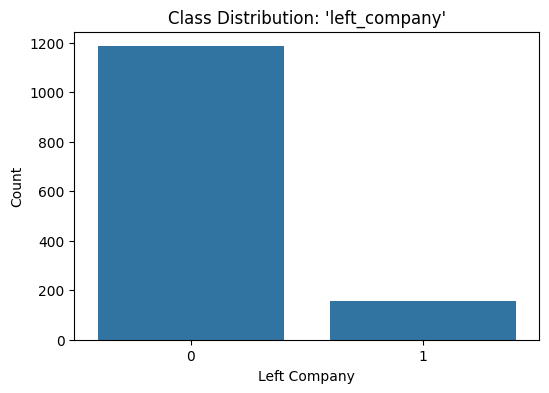

___________________________________________
___________________________________________
___________________________________________
___________________________________________


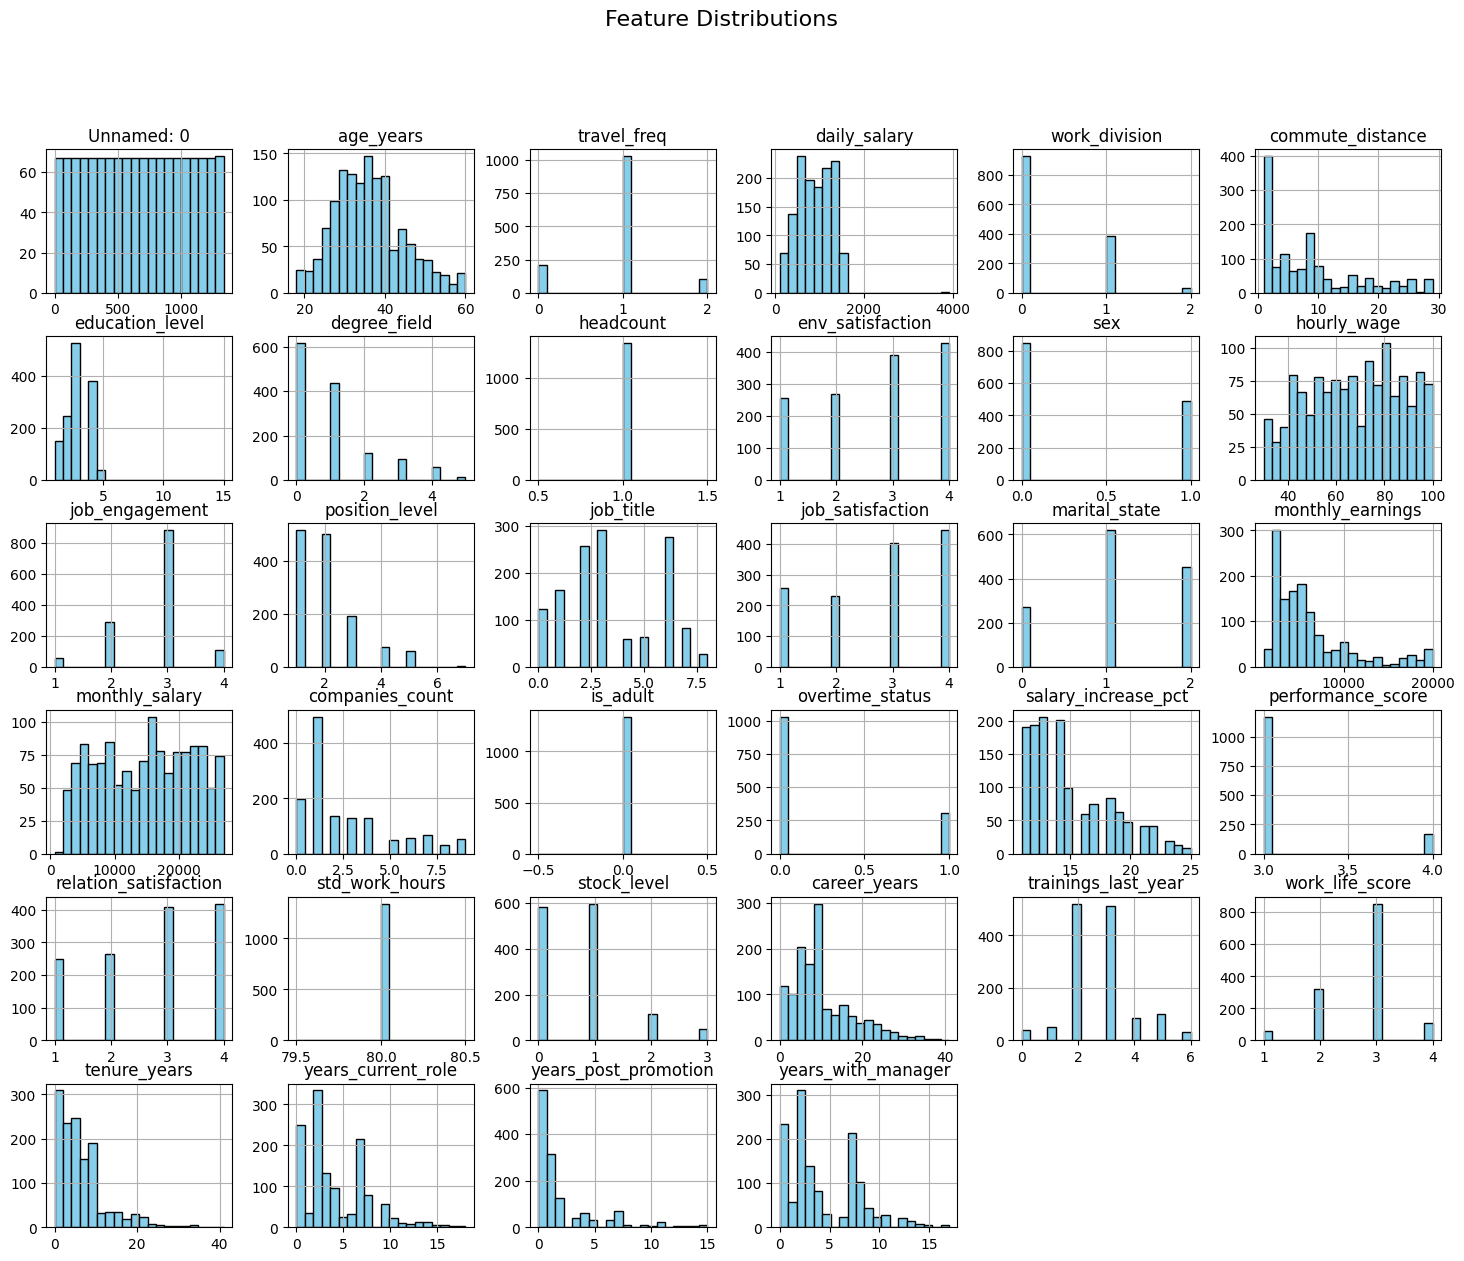

___________________________________________
___________________________________________
___________________________________________
___________________________________________


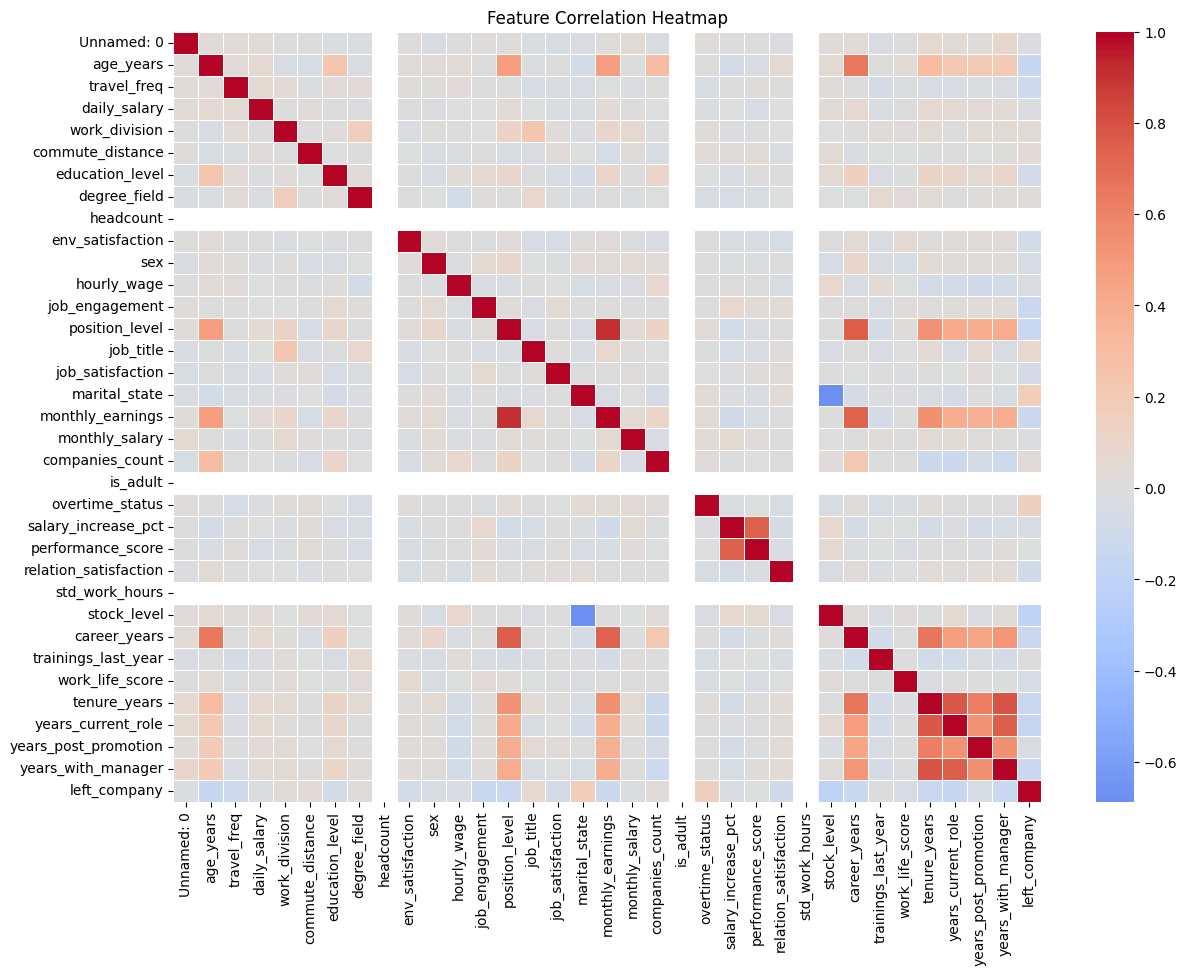

___________________________________________
___________________________________________
___________________________________________
___________________________________________


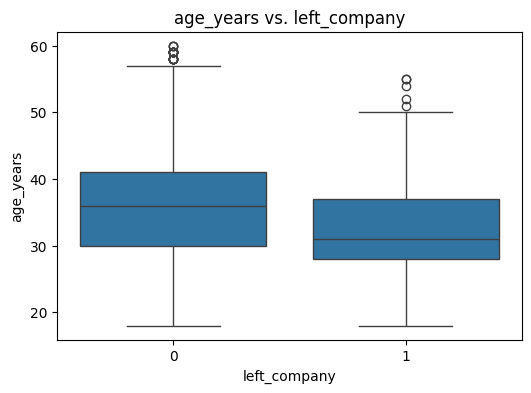

___________________________________________


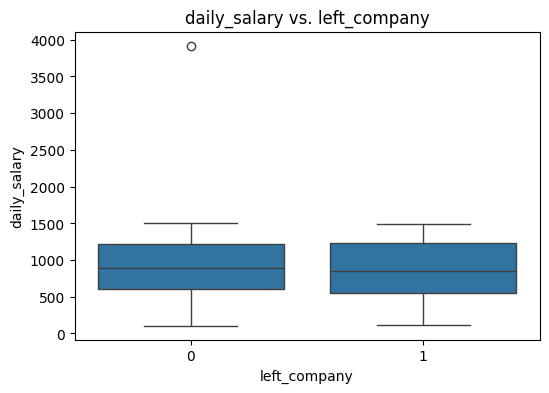

___________________________________________


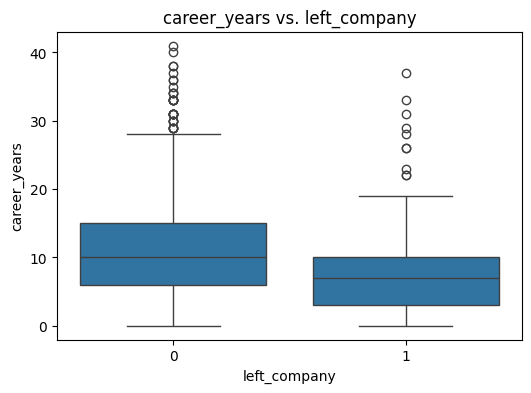

___________________________________________


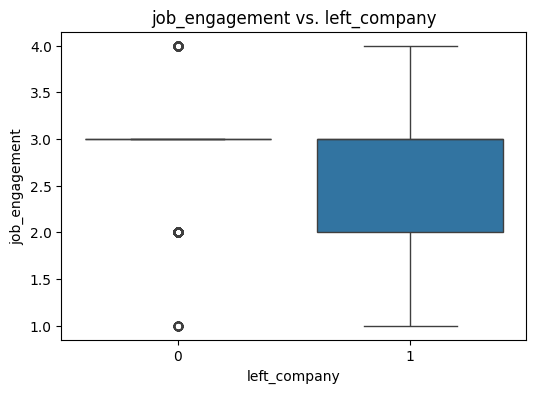

___________________________________________


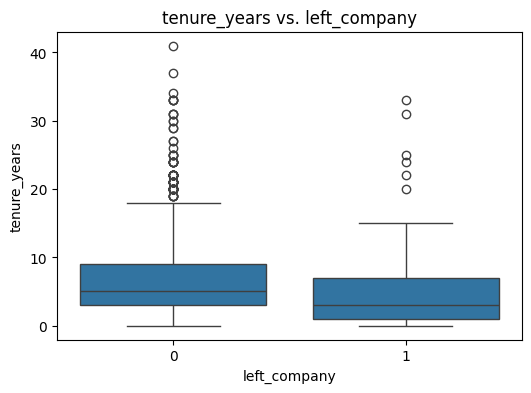

___________________________________________


In [ ]:
target_col = 'left_company'

# 1. Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x=target_col, data=train_df)
plt.title("Class Distribution: 'left_company'")
plt.xlabel("Left Company")
plt.ylabel("Count")
plt.show()
print("___________________________________________")
print("___________________________________________")
print("___________________________________________")
print("___________________________________________")
# 2. Distribution of Numerical Features
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if col != target_col]

train_df[num_cols].hist(bins=20, figsize=(18, 14), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()
print("___________________________________________")
print("___________________________________________")
print("___________________________________________")
print("___________________________________________")
# 3. Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = train_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
print("___________________________________________")
print("___________________________________________")
print("___________________________________________")
print("___________________________________________")
# 4. Feature Relationships with Target
selected_features = ['age_years', 'daily_salary', 'career_years', 'tenure_years']
for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target_col, y=feature, data=train_df)
    plt.title(f"{feature} vs. {target_col}")
    plt.show()
    print("___________________________________________")


## 2. Baseline Model

In [ ]:
from sklearn import model_selection
feature_cols = [col for col in train_df.columns if col not in ['left_company', 'Unnamed: 0']]
X = train_df[feature_cols]
y = train_df['left_company']
X_sample = test_df[feature_cols]
data1 = train_df.copy(deep=True)
data_cleaner = [data1, test_df]

feature_cols = [col for col in train_df.columns if col not in ['left_company', 'Unnamed: 0', 'ID']]
corr = train_df[feature_cols].corr()
top_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
print(top_pairs)

numerics = train_df.select_dtypes(include='number').drop(columns=['left_company']).columns

scaler = StandardScaler()
train_df[numerics] = scaler.fit_transform(train_df[numerics])
test_df[numerics] = scaler.transform(test_df[numerics])

#split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_sample_scaled = scaler.transform(X_sample)

models = [
    ensemble.AdaBoostClassifier(),
    ensemble.BaggingClassifier(),
    ensemble.ExtraTreesClassifier(),
    ensemble.GradientBoostingClassifier(),
    ensemble.RandomForestClassifier(),
    gaussian_process.GaussianProcessClassifier(),
    linear_model.LogisticRegressionCV(),
    linear_model.PassiveAggressiveClassifier(),
    linear_model.RidgeClassifierCV(),
    linear_model.SGDClassifier(),
    linear_model.Perceptron(),
    naive_bayes.BernoulliNB(),
    naive_bayes.GaussianNB(),
    neighbors.KNeighborsClassifier(),
    svm.SVC(probability=True),
    svm.NuSVC(probability=True),
    svm.LinearSVC(),
    tree.DecisionTreeClassifier(),
    tree.ExtraTreeClassifier(),
    discriminant_analysis.LinearDiscriminantAnalysis(),
    discriminant_analysis.QuadraticDiscriminantAnalysis(),
    XGBClassifier(),
]

models = [
    LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    SVC(probability=True, class_weight='balanced', random_state=42)
]

cv_split = model_selection.StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

model_col = [
    ' Name',
    ' Parameters',
    ' Train Accuracy Mean',
    ' Test Accuracy Mean',
    ' Test Accuracy 3*STD',
    ' Time'
]

compare = pd.DataFrame(columns=model_col)
predict = pd.DataFrame(data1['left_company'].copy())

for row_index, alg in enumerate(models):
    name = alg.__class__.__name__
    compare.loc[row_index, ' Name'] = name
    compare.loc[row_index, ' Parameters'] = str(alg.get_params())
    try:
        cv_results = model_selection.cross_validate(
            alg,
            data1[feature_cols],
            data1['left_company'],
            cv=cv_split,
            return_train_score=True,
            n_jobs=-1,
            error_score='raise'  # raises errors instead of suppressing
        )
        compare.loc[row_index, ' Time'] = cv_results['fit_time'].mean()
        compare.loc[row_index, ' Train Accuracy Mean'] = cv_results['train_score'].mean()
        compare.loc[row_index, ' Test Accuracy Mean'] = cv_results['test_score'].mean()
        compare.loc[row_index, ' Test Accuracy 3*STD'] = cv_results['test_score'].std() * 3
        alg.fit(data1[feature_cols], data1['left_company'])
        predict[name] = alg.predict(data1[feature_cols])
    except Exception as e:
        print(f"Model {name} failed: {e}")
        compare.loc[row_index, [' Time', ' Train Accuracy Mean', ' Test Accuracy Mean', ' Test Accuracy 3*STD']] = [None]*4
        predict[name] = None

compare.sort_values(by=' Test Accuracy Mean', ascending=False, inplace=True)
print(compare)



position_level       monthly_earnings      0.906910
tenure_years         years_with_manager    0.792115
                     years_current_role    0.775484
years_current_role   years_with_manager    0.754404
position_level       career_years          0.753900
salary_increase_pct  performance_score     0.746755
monthly_earnings     career_years          0.735746
marital_state        stock_level           0.686920
career_years         tenure_years          0.660944
age_years            career_years          0.651054
dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                     Name                                         Parameters  \
1  RandomForestClassifier  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...   
0      LogisticRegression  {'C': 1.0, 'class_weight': 'balanced', 'dual':...   
2                     SVC  {'C': 1.0, 'break_ties': False, 'cache_size': ...   

  Train Accuracy Mean Test Accuracy Mean Test Accuracy 3*STD      Time  
1                 1.0           0.881437            0.027086  0.694818  
0            0.750685           0.725627            0.160732   0.83782  
2            0.575277           0.570481            0.109323  0.758453  


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression (No Class Weights):
Precision: 0.6666666666666666
Recall: 0.06451612903225806
F1 Score: 0.11764705882352941
ROC AUC: 0.7258064516129032


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression (With Class Weights):
Precision: 0.22580645161290322
Recall: 0.6774193548387096
F1 Score: 0.3387096774193548
ROC AUC: 0.7637571157495255


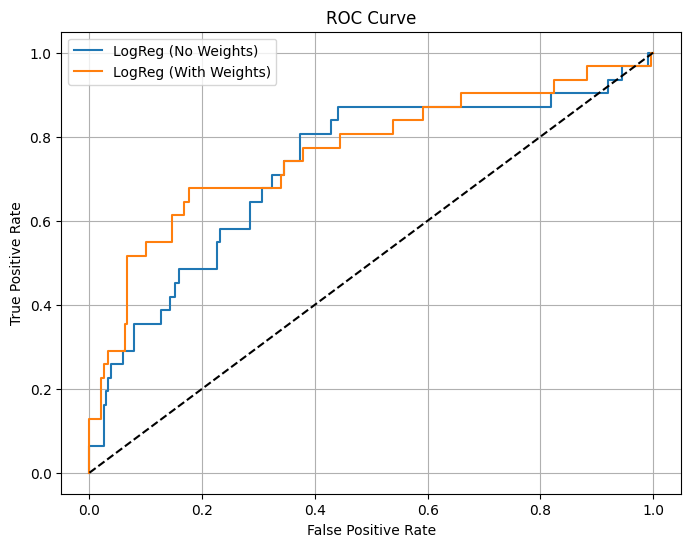

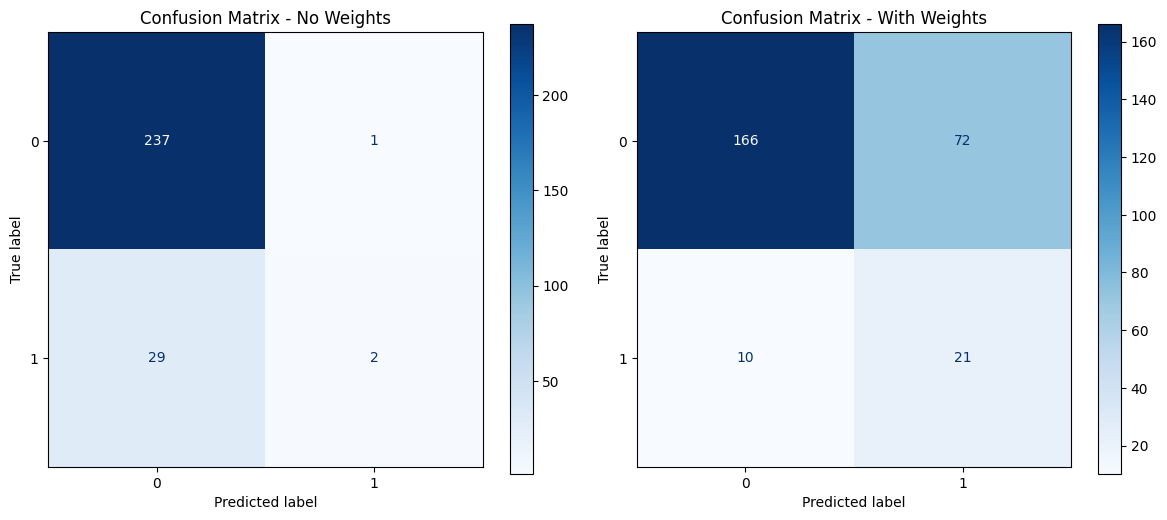

In [ ]:
# Logistic Regression without class weights
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_val)
y_proba = lr.predict_proba(X_val)[:, 1]

print("\nLogistic Regression (No Class Weights):")
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_proba))

# Logistic Regression with class weights
lr_w = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_w.fit(X_train, y_train)
y_pred_w = lr_w.predict(X_val)
y_proba_w = lr_w.predict_proba(X_val)[:, 1]

print("\nLogistic Regression (With Class Weights):")
print("Precision:", precision_score(y_val, y_pred_w))
print("Recall:", recall_score(y_val, y_pred_w))
print("F1 Score:", f1_score(y_val, y_pred_w))
print("ROC AUC:", roc_auc_score(y_val, y_proba_w))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba)
fpr_w, tpr_w, _ = roc_curve(y_val, y_proba_w)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='LogReg (No Weights)')
plt.plot(fpr_w, tpr_w, label='LogReg (With Weights)')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(lr, X_val, y_val, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix - No Weights")
ConfusionMatrixDisplay.from_estimator(lr_w, X_val, y_val, ax=ax[1], cmap='Blues')
ax[1].set_title("Confusion Matrix - With Weights")
plt.tight_layout()
plt.show()


## 3. Advanced Models

In [ ]:
# KNN Pipeline
knn_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
knn_pipeline.fit(X_train, y_train)
y_pred_knn = knn_pipeline.predict(X_val)
y_proba_knn = knn_pipeline.predict_proba(X_val)[:, 1]

# Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('nb', GaussianNB())
])
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_val)
y_proba_nb = nb_pipeline.predict_proba(X_val)[:, 1]

# RBF SVM pipeline with SMOTE
pipeline_rbf = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid_rbf = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01, 0.1, 1]
}

grid_rbf = GridSearchCV(pipeline_rbf, param_grid_rbf, cv=5, scoring='f1', n_jobs=-1)
grid_rbf.fit(X_train, y_train)

best_rbf = grid_rbf.best_estimator_
y_pred_rbf = best_rbf.predict(X_val)
y_proba_rbf = best_rbf.predict_proba(X_val)[:, 1]

def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n=== {name} ===")
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC AUC Score:", roc_auc_score(y_true, y_proba))
"""    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, label=name)"""

# RBF SVM
evaluate_model("SVM RBF", y_val, y_pred_rbf, y_proba_rbf)
# KNN
evaluate_model("KNN", y_val, y_pred_knn, y_proba_knn)
# Naive Bayes
evaluate_model("Naive Bayes", y_val, y_pred_nb, y_proba_nb)


=== SVM RBF ===
F1 Score: 0.28776978417266186
ROC AUC Score: 0.5969775006776904

=== KNN ===
F1 Score: 0.1889763779527559
ROC AUC Score: 0.5040661425860666

=== Naive Bayes ===
F1 Score: 0.34234234234234234
ROC AUC Score: 0.701409596096503


Fitting 3 folds for each of 4 candidates, totalling 12 fits

=== Optimized SVM Linear ===
Best Parameters: {'svc__estimator__C': 1, 'svc__estimator__class_weight': 'balanced'}
F1 Score: 0.4225352112676056
ROC AUC Score: 0.7854432095418813


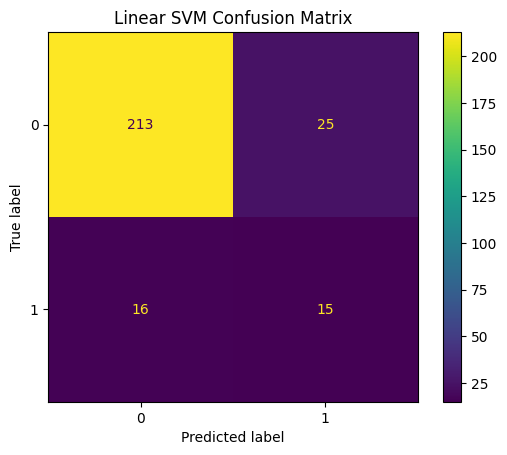

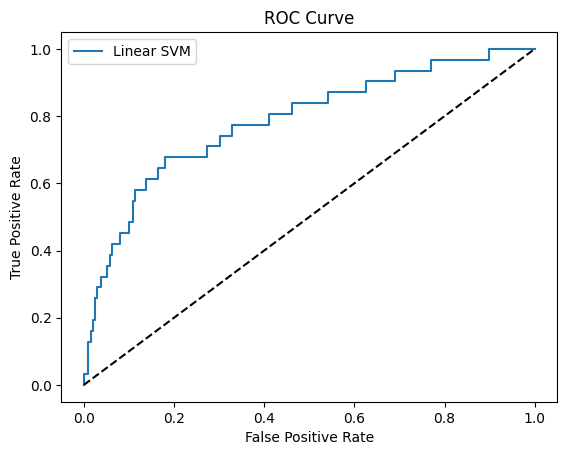

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

# Optimized Linear SVM pipeline with SMOTE
pipeline_linear = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),
    ('svc', CalibratedClassifierCV(
        estimator=LinearSVC(random_state=42, dual=False, max_iter=10000),
        method='sigmoid',
        cv=3
    ))
])

param_grid_linear = {
    'svc__estimator__C': [0.1, 1],
    'svc__estimator__class_weight': [None, 'balanced']
}


grid_linear = GridSearchCV(
    pipeline_linear,
    param_grid_linear,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_linear.fit(X_train, y_train)


best_linear = grid_linear.best_estimator_
y_pred_linear = best_linear.predict(X_val)
y_proba_linear = best_linear.predict_proba(X_val)[:, 1]


print(f"\n=== Optimized SVM Linear ===")
print(f"Best Parameters: {grid_linear.best_params_}")
print("F1 Score:", f1_score(y_val, y_pred_linear))
print("ROC AUC Score:", roc_auc_score(y_val, y_proba_linear))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_linear)
plt.title("Linear SVM Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_proba_linear)
plt.plot(fpr, tpr, label='Linear SVM')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Bonus

In [ ]:

class SimpleRandomForest:
    def __init__(self, n_estimators=10, max_features='sqrt', max_depth=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.trees = []
        self.features_list = []
        self.column_names = None

    def bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X.iloc[indices], y.iloc[indices]

    def fit(self, X, y):
        self.trees = []
        self.features_list = []
        self.column_names = X.columns.tolist()

        n_features = X.shape[1]

        for _ in range(self.n_estimators):
            X_sample, y_sample = self.bootstrap_sample(X, y)

            if self.max_features == 'sqrt':
                n_feats = int(np.sqrt(n_features))
            else:
                n_feats = n_features

            features = np.random.choice(n_features, n_feats, replace=False)
            self.features_list.append(features)

            tree = DecisionTreeClassifier(max_depth=self.max_depth)
            tree.fit(X_sample.iloc[:, features], y_sample)
            self.trees.append(tree)

    def predict(self, X):
        predictions = []
        for tree, feats in zip(self.trees, self.features_list):
            preds = tree.predict(X.iloc[:, feats])
            predictions.append(preds)

        predictions = np.array(predictions).T
        final_preds = [Counter(row).most_common(1)[0][0] for row in predictions]
        return np.array(final_preds)

    def predict_proba(self, X):
        probas = []
        for tree, feats in zip(self.trees, self.features_list):
            proba = tree.predict_proba(X.iloc[:, feats])
            probas.append(proba)


        avg_proba = np.mean(probas, axis=0)
        return avg_proba

In [ ]:
# From-scratch Random Forest
my_rf = SimpleRandomForest(n_estimators=10, max_depth=5)
my_rf.fit(X_train, y_train)
y_pred_my_rf = my_rf.predict(X_val)
y_proba_my_rf = my_rf.predict_proba(X_val)[:, 1]
evaluate_model("Simple RF (from scratch)", y_val, y_pred_my_rf, y_proba_my_rf)

# Library Random Forest
from sklearn.ensemble import RandomForestClassifier
lib_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
lib_rf.fit(X_train, y_train)
y_pred_lib_rf = lib_rf.predict(X_val)
y_proba_lib_rf = lib_rf.predict_proba(X_val)[:, 1]
evaluate_model("Library RF", y_val, y_pred_lib_rf, y_proba_lib_rf)

# k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_val)
y_proba_knn = knn.predict_proba(X_val)[:, 1]
evaluate_model("KNN", y_val, y_pred_knn, y_proba_knn)

# Naïve Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_val)
y_proba_nb = nb.predict_proba(X_val)[:, 1]
evaluate_model("Naive Bayes", y_val, y_pred_nb, y_proba_nb)


=== Simple RF (from scratch) ===
F1 Score: 0.0625
ROC AUC Score: 0.7251287611818923

=== Library RF ===
F1 Score: 0.11764705882352941
ROC AUC Score: 0.8152615885063702

=== KNN ===
F1 Score: 0.0
ROC AUC Score: 0.5372729737056112

=== Naive Bayes ===
F1 Score: 0.3953488372093023
ROC AUC Score: 0.7191650853889943


### 4.handling imbalanced data:

In [ ]:

# Logistic Regression with class_weight
lr_balanced = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_lr = lr_balanced.predict(X_val)
y_proba_lr = lr_balanced.predict_proba(X_val)[:, 1]
evaluate_model("Logistic Regression (class_weight)", y_val, y_pred_lr, y_proba_lr)

# SVM with class_weight
svm_balanced = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_balanced.fit(X_train, y_train)
y_pred_svm = svm_balanced.predict(X_val)
y_proba_svm = svm_balanced.predict_proba(X_val)[:, 1]
evaluate_model("SVM RBF (class_weight)", y_val, y_pred_svm, y_proba_svm)

proba_lr = lr_balanced.predict_proba(X_val)[:, 1]

custom_threshold = 0.3
y_pred_thresh = (proba_lr >= custom_threshold).astype(int)

evaluate_model("LogReg + Threshold = 0.3", y_val, y_pred_thresh, proba_lr)






=== Logistic Regression (class_weight) ===
F1 Score: 0.42857142857142855
ROC AUC Score: 0.8126863648685281

=== SVM RBF (class_weight) ===
F1 Score: 0.25
ROC AUC Score: 0.6223908918406071

=== LogReg + Threshold = 0.3 ===
F1 Score: 0.3312883435582822
ROC AUC Score: 0.8126863648685281


## 5.model stacking (optional)


=== Stacked Model ===
F1 Score: 0.11764705882352941
ROC AUC Score: 0.8281377066955815


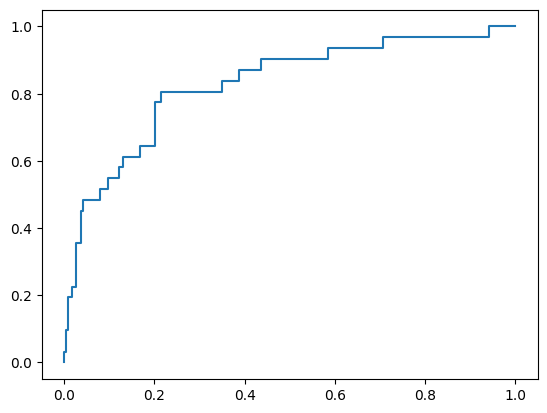

In [ ]:

# Base models
base_models = [
    ('lr', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
]

# Meta learner
meta_model = LogisticRegression()

# Stacking model
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_val)
y_proba_stack = stacking_clf.predict_proba(X_val)[:, 1]

evaluate_model("Stacked Model", y_val, y_pred_stack, y_proba_stack)
fpr_stack, tpr_stack, _ = roc_curve(y_val, y_proba_stack)
plt.plot(fpr_stack, tpr_stack, label='Stacked Model')


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:18:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:18:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:18:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:18:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:18:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Best threshold by F1 score: 0.23
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       238
           1       0.55      0.52      0.53        31

    accuracy                           0.90       269
   macro avg       0.74      0.73      0.74       269
weighted avg       0.89      0.90      0.89       269



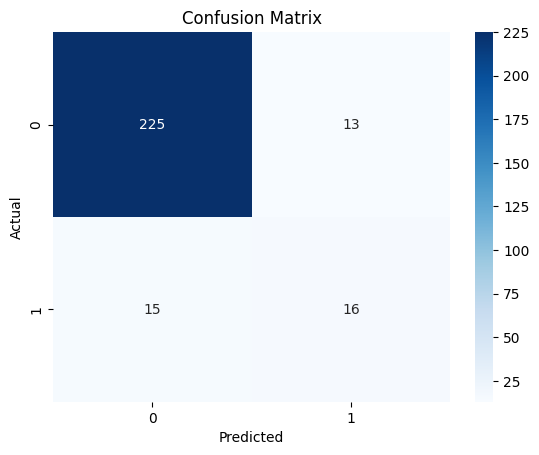

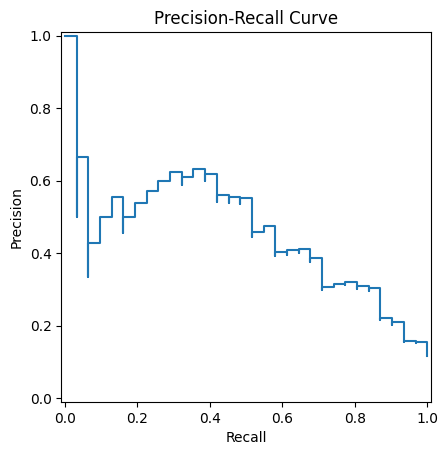

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


LR = LogisticRegression(class_weight='balanced', random_state=42)
RF = RandomForestClassifier(class_weight='balanced', random_state=42)
XGB = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

SVC_model = SVC(probability=True, random_state=42)

vote = VotingClassifier(
    estimators=[('lr', LR), ('rf', RF), ('svc', SVC_model), ('xgb', XGB)],
    voting='soft',
    weights=[1, 2, 1, 2]
)
rfe_selector = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=30)
X_train_RFE = rfe_selector.fit_transform(X_train_scaled, y_train)

vote.fit(X_train_RFE, y_train)

#  5-fold CV
calibrated_vote = CalibratedClassifierCV(vote, cv=5)
calibrated_vote.fit(X_train_RFE, y_train)
X_val_RFE = rfe_selector.transform(X_val_scaled)

val_probs = calibrated_vote.predict_proba(X_val_RFE)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold by F1 score: {best_threshold:.2f}")
val_preds = (val_probs >= best_threshold).astype(int)
print(classification_report(y_val, val_preds))

cm = confusion_matrix(y_val, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
from sklearn.metrics import PrecisionRecallDisplay

pr_display = PrecisionRecallDisplay(precision=precisions, recall=recalls)
pr_display.plot()
plt.title('Precision-Recall Curve')
plt.show()

X_sample_RFE = rfe_selector.transform(X_sample_scaled)
sample_probs = vote.predict_proba(X_sample_RFE)[:, 1]

sample_preds = (sample_probs >= 0.22).astype(int)

output_df = pd.DataFrame({
    "ID": test_df.index,
    "left_company": sample_preds
})

output_df.to_csv("submission.csv", index=False)

from google.colab import files
files.download("submission.csv")